# OSNet-AIN x1.0 — HPO на изображениях с автоматическими масками

Основан на `variant_02_hpo_bnneck_supcon/train_osnet_hpo.ipynb` и использует тот же `training.hpo`: 16 trials × 8 эпох → top-4 до 20 → top-2 × 3 seed до 30 → обучение выбранной конфигурации на всех outer-train identity.

**Во всех ветвях используются изображения с автоматическими непрозрачными масками YOLO11**: обучение, обе ветви consistency loss, HPO-validation, calibration и итоговые query/gallery. YOLO заморожен: confidence=0.20, margin=0.10. Маска применяется до resize и аугментаций. Ненайденная область остаётся незакрытой — идеальное покрытие не гарантируется.

Исходные фото не меняются; кэшируются только координаты, а не копии датасета. Инициализация OSNet — из **стокового ONNX, как в исходном HPO**, не из активных весов MVP. Старые ноутбуки, веса и MVP не заменяются.

Обучение запускается только при выполнении ячеек этого ноутбука.

## 1. Окружение и параметры

Откройте notebook с ядром репозитория `.venv/bin/python`, затем **Restart Kernel → Run All**. Все этапы по умолчанию включены. Длительное обучение сейчас не запускалось.

Сохраняется прежнее окружение `requirements-train.txt` и локальный YOLO runtime. Ничего автоматически не устанавливается и не скачивается. Если ядро выбрано неверно, переключите его, а не устанавливайте зависимости в глобальный Python.

OSNet автоматически использует CUDA → MPS → CPU. Подготовка масок по умолчанию на CPU, как в парном сравнении; она выполняется один раз. Время эпохи и ETA выводятся существующим HPO-циклом. Длительность всего поиска заранее не гарантируется.

Для нового независимого запуска меняйте `RUN_NAME`. Для продолжения оставляйте прежнее имя и параметры. **Не запускайте два ядра одновременно с одним RUN_NAME.**

In [1]:
import gc
import json
import os
import sys
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'backend').exists():
    ROOT = ROOT.parent
assert (ROOT / 'backend').exists(), 'Не найден корень Car-classification-MSK'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from backend.core import DATASET, STOCK_MODEL
from training.audit import load_crop
from training.hpo import (
    ExperimentConfig, config_from_trial, continue_top_candidates, experiment_losses,
    hpo_identities, initialize_experiment, load_hpo_study, make_optimizer,
    prepare_experiment, run_finalist_seeds, run_hpo, set_epoch_learning_rates,
)
from training.mask_calibration import _load
from training.masked_hpo import (
    VARIANT, attach_masks, cache_masks, export_selected, fit_masked_selected,
    freeze_run, prepare_protocol,
)
from training.pipeline import select_device, set_seed, split_summary
from training.preprocessing import mask_crop
from training.stage6 import write_json

RUN_NAME = 'masked_run_01'
assert RUN_NAME not in ('', '.', '..') and Path(RUN_NAME).name == RUN_NAME
VARIANT_DIR = VARIANT
RESULTS_DIR = VARIANT_DIR / 'results' / RUN_NAME
WEIGHTS_DIR = VARIANT_DIR / 'weights' / RUN_NAME
SELECTED_RESULTS = RESULTS_DIR / 'selected'
SELECTED_WEIGHTS = WEIGHTS_DIR / 'selected'
CACHE_PATH = VARIANT_DIR / 'results/cache/automatic_masks.json'

TARGET_TRIALS = 16
TRIAL_EPOCHS = 8
TOP_CANDIDATES = 4
PROMOTION_EPOCHS = 20
FINALISTS = 2
FINALIST_EPOCHS = 30
FINALIST_SEEDS = (20260915, 20260916, 20260917)
OUTER_EPOCHS = 30

RUN_MASKS = True
RUN_HPO = True
RUN_STAGE2 = True
RUN_STAGE3 = True
RUN_SELECTED_TRAINING = True
RUN_EXPORT = True

DEVICE = select_device()
MASK_DEVICE = 'cpu'
torch.set_num_threads(2)
set_seed(20260915)
print('Python:', sys.executable, '| torch:', torch.__version__)
print('OSNet:', DEVICE, '| YOLO masks:', MASK_DEVICE)
print('Variant:', VARIANT_DIR, '| run:', RUN_NAME)

Python: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/bin/python | torch: 2.14.0
OSNet: mps | YOLO masks: cpu
Variant: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/OSNet-AIN-x1.0/variant_08_masked_hpo | run: masked_run_01


## 2. Проверка данных и разбиений

Внешние train/calibration/validation сохраняются. Внутреннее HPO-разбиение строится по связанным идентичностям/точным кадрам. **Все машины и кадры из detector train/val/holdout остаются на HPO-train стороне**: YOLO не должен заранее видеть HPO-validation.

Поэтому inner split отличается от старого варианта 2: его HPO-метрики нельзя напрямую сравнивать со старым study. test_query.csv и test_gallery.csv не используются. Исходный splits.json только читается; при несоответствии исходных файлов выполнение остановится.

In [2]:
source_rows, split, protocol = prepare_protocol(VARIANT_DIR, DATASET)
print(json.dumps(split_summary(source_rows, split), ensure_ascii=False, indent=2))
hpo_train_ids, hpo_validation_ids = hpo_identities(split)
print('HPO train:', len(hpo_train_ids), '| HPO validation:', len(hpo_validation_ids))
print('Frozen mask policy:', protocol['policy'])

Проверка исходных кадров:   0%|          | 0/9556 [00:00<?, ?it/s]

{
  "train": {
    "identities": 925,
    "images": 5717
  },
  "calibration": {
    "identities": 307,
    "images": 1903
  },
  "validation": {
    "identities": 309,
    "images": 1936
  }
}
HPO train: 740 | HPO validation: 185
Frozen mask policy: {'confidence': 0.2, 'margin': 0.1}


## 3. Автоматические маски для всех train.csv кропов

YOLO работает один раз; кэш сохраняется каждые 100 изображений. После прерывания подготовка продолжится. Пустой список рамок означает «детектор ничего не нашёл», а не ручное подтверждение отсутствия анонимизации. Отсутствующая запись считается ошибкой.

Обе версии изображения для consistency loss уже замаскированы: немаскированного teacher здесь нет. Аугментации могут изменить цвет/границу чёрного прямоугольника, но не восстановят закрытое содержимое.

In [3]:
if RUN_MASKS:
    mask_cache = cache_masks(source_rows, protocol, CACHE_PATH, MASK_DEVICE, DATASET)
else:
    # Даже при пропуске YOLO проверяем подпись кэша и точное покрытие строк.
    from training.audit import digest
    mask_cache = _load(CACHE_PATH, {'protocol': digest(protocol), 'device': MASK_DEVICE})
rows = attach_masks(source_rows, mask_cache)
budget = {
    'trials': TARGET_TRIALS, 'trial_epochs': TRIAL_EPOCHS,
    'top_candidates': TOP_CANDIDATES, 'promotion_epochs': PROMOTION_EPOCHS,
    'finalists': FINALISTS, 'finalist_epochs': FINALIST_EPOCHS,
    'seeds': list(FINALIST_SEEDS), 'outer_epochs': OUTER_EPOCHS,
}
run_signature = freeze_run(RESULTS_DIR, protocol, CACHE_PATH, budget)
with_masks = sum(bool(r['mask_rectangles']) for r in rows)
print(f'Кропов: {len(rows)} | с масками: {with_masks} | без детекций: {len(rows)-with_masks}')
print('Прямоугольников:', sum(len(r['mask_rectangles']) for r in rows))
assert len(rows) == len(source_rows) and all('mask_rectangles' in r for r in rows)

Маски: 100/9556 | прошло 00:00:04 | ETA 00:06:57
Маски: 200/9556 | прошло 00:00:08 | ETA 00:06:31
Маски: 300/9556 | прошло 00:00:12 | ETA 00:06:25
Маски: 400/9556 | прошло 00:00:17 | ETA 00:06:26
Маски: 500/9556 | прошло 00:00:21 | ETA 00:06:27
Маски: 600/9556 | прошло 00:00:26 | ETA 00:06:27
Маски: 700/9556 | прошло 00:00:30 | ETA 00:06:24
Маски: 800/9556 | прошло 00:00:34 | ETA 00:06:16
Маски: 900/9556 | прошло 00:00:39 | ETA 00:06:12
Маски: 1000/9556 | прошло 00:00:43 | ETA 00:06:06
Маски: 1100/9556 | прошло 00:00:47 | ETA 00:05:59
Маски: 1200/9556 | прошло 00:00:51 | ETA 00:05:52
Маски: 1300/9556 | прошло 00:00:55 | ETA 00:05:47
Маски: 1400/9556 | прошло 00:00:59 | ETA 00:05:42
Маски: 1500/9556 | прошло 00:01:03 | ETA 00:05:38
Маски: 1600/9556 | прошло 00:01:07 | ETA 00:05:33
Маски: 1700/9556 | прошло 00:01:11 | ETA 00:05:28
Маски: 1800/9556 | прошло 00:01:15 | ETA 00:05:24
Маски: 1900/9556 | прошло 00:01:19 | ETA 00:05:20
Маски: 2000/9556 | прошло 00:01:23 | ETA 00:05:15
Маски: 21

### Визуальная проверка входа

Шесть примеров только из HPO-train: слева исходный кроп, справа именно тот замаскированный кроп, который далее попадает в resize/аугментации. Копии фотографий на диск не сохраняются.

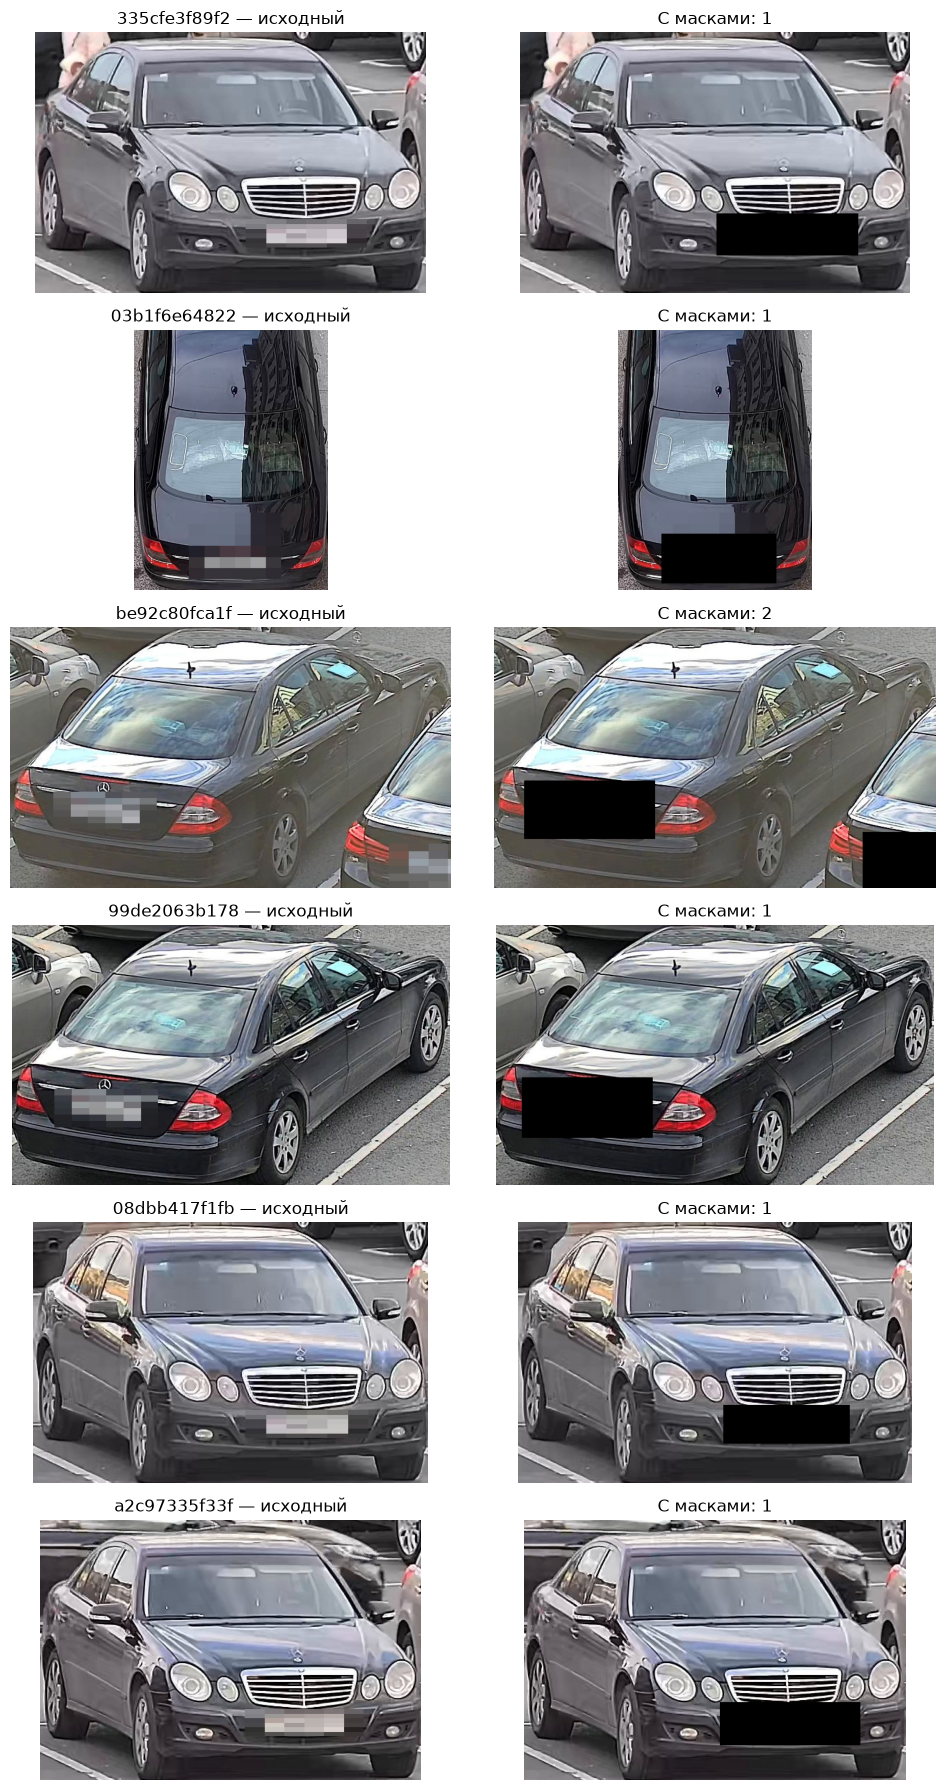

In [4]:
preview_rows = [r for r in rows if r['vehicle_id'] in set(hpo_train_ids) and r['mask_rectangles']][:6]
assert preview_rows, 'Нет ни одной найденной маски в train — проверьте детектор'
fig, axes = plt.subplots(len(preview_rows), 2, figsize=(10, 3 * len(preview_rows)), squeeze=False)
for pair, row in zip(axes, preview_rows):
    crop = load_crop(row, DATASET)
    pair[0].imshow(crop)
    pair[1].imshow(mask_crop(crop, row['mask_rectangles']))
    pair[0].set_title(row['image_id'][:12] + ' — исходный')
    pair[1].set_title(f"С масками: {len(row['mask_rectangles'])}")
    for ax in pair:
        ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Smoke test на маскированном batch

P=16/K=2, camera-aware sampler, отдельный LR encoder/head, BNNeck и SupCon. Это один проверочный шаг на временной модели; он не меняет стартовые веса основного поиска.

In [5]:
SMOKE_CONFIG = ExperimentConfig(epochs=1, metric_loss='supcon', use_bnneck=True)
smoke_rows, smoke_labels, smoke_sampler, smoke_loader = prepare_experiment(
    rows, hpo_train_ids, SMOKE_CONFIG, DATASET)
assert all('mask_rectangles' in r for r in smoke_rows)
clean, robust, labels, _ = next(iter(smoke_loader))
assert clean.shape == robust.shape == (32, 3, 208, 208)
assert len(set(labels.tolist())) == 16
assert all(labels.tolist().count(label) == 2 for label in set(labels.tolist()))
smoke_model, loaded = initialize_experiment(len(smoke_labels), SMOKE_CONFIG, DEVICE, STOCK_MODEL)
smoke_optimizer = make_optimizer(smoke_model, SMOKE_CONFIG)
set_epoch_learning_rates(smoke_optimizer, SMOKE_CONFIG, 0, 1)
smoke_optimizer.zero_grad(set_to_none=True)
losses = experiment_losses(smoke_model, clean.to(DEVICE), robust.to(DEVICE), labels.to(DEVICE), SMOKE_CONFIG)
assert all(torch.isfinite(v) for v in losses.values())
losses['loss'].backward()
smoke_optimizer.step()
print('Stock tensors:', loaded)
print({name: round(float(value.detach()), 6) for name, value in losses.items()})
del smoke_model, smoke_optimizer, smoke_loader, clean, robust, labels, losses
gc.collect()
if DEVICE.type == 'mps': torch.mps.empty_cache()
if DEVICE.type == 'cuda': torch.cuda.empty_cache()

Stock tensors: 559
{'loss': 7.849809, 'classification': 6.633955, 'metric': 1.190356, 'consistency': 0.254974, 'accuracy': 0.0}


## 5. Optuna: 16 конфигураций по 8 эпох

Тот же поиск, что в варианте 2: Triplet/SupCon, BNNeck on/off, encoder LR 5e−5…3e−4, head multiplier 5/10, weight decay, metric/consistency weights и Triplet margin. Median pruner начинает останавливать слабые trials не раньше четвёртой эпохи.

Все оценки ниже — **на маскированных query и gallery**. Study и веса находятся только в новой папке. При повторном Run All завершённые trials не повторяются; оборванный trial может быть заменён новым, без точного продолжения с середины эпохи.

In [6]:
if RUN_HPO:
    study = run_hpo(rows, split, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
                    target_trials=TARGET_TRIALS, trial_epochs=TRIAL_EPOCHS, dataset=DATASET)
else:
    study = load_hpo_study(RESULTS_DIR)
print('Best trial:', study.best_trial.number, '| inner mAP@10:', study.best_value)
print(json.dumps(study.best_trial.params, ensure_ascii=False, indent=2))

[I 2026-09-21 13:37:16,090] A new study created in RDB with name: osnet_ain_x1_0_variant_02


epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 1/8 | осталось эпох: 7 | эпоха: 00:00:47 | прошло: 00:00:47 | ETA: 00:05:27 | best mAP: 0.7564


epoch 2:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 2/8 | осталось эпох: 6 | эпоха: 00:00:47 | прошло: 00:01:34 | ETA: 00:04:41 | best mAP: 0.7564


...

Epoch 5/8 | осталось эпох: 3 | эпоха: 00:00:47 | прошло: 00:03:56 | ETA: 00:02:21 | best mAP: 0.7785


epoch 6:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 6/8 | осталось эпох: 2 | эпоха: 00:00:47 | прошло: 00:04:43 | ETA: 00:01:34 | best mAP: 0.7785


[I 2026-09-21 14:55:06,693] Trial 15 pruned. 


Best trial: 5 | inner mAP@10: 0.7912615293865294
{
  "metric_loss": "supcon",
  "encoder_lr": 0.00011940564013110387,
  "head_lr_multiplier": 10.0,
  "weight_decay": 6.069870050850335e-05,
  "metric_weight": 1.4948762510958067,
  "consistency_weight": 0.22571745222502657,
  "use_bnneck": true
}


## 6. Top-4 до 20 эпох, затем top-2 × 3 seed до 30

Top-4 продолжаются с последних checkpoint первого этапа. Два финалиста обучаются заново из stock на трёх seed; победитель выбирается по среднему лучшему inner mAP@10. Продолжение с checkpoint сохраняет эпоху/optimizer, но не гарантирует побитового совпадения случайных аугментаций с непрерывным запуском.

In [7]:
if RUN_STAGE2:
    stage2 = continue_top_candidates(rows, split, study, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
                                    top_k=TOP_CANDIDATES, target_epochs=PROMOTION_EPOCHS, dataset=DATASET)
else:
    stage2 = json.loads((RESULTS_DIR / 'stage2_top4_summary.json').read_text())
print('Top-4:', [(r['trial_number'], round(r['best_mAP'], 4)) for r in stage2['candidates']])

if RUN_STAGE3:
    stage3 = run_finalist_seeds(rows, split, study, stage2, DEVICE, RESULTS_DIR, WEIGHTS_DIR,
                               top_k=FINALISTS, target_epochs=FINALIST_EPOCHS,
                               seeds=FINALIST_SEEDS, dataset=DATASET)
else:
    stage3 = json.loads((RESULTS_DIR / 'stage3_top2_seeds_summary.json').read_text())
winner = next(t for t in study.trials if t.number == stage3['best_trial_number'])
print('Winner:', winner.number)
print(json.dumps(stage3['finalists'], ensure_ascii=False, indent=2))

epoch 9:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 9/20 | осталось эпох: 11 | эпоха: 00:00:49 | прошло: 00:00:49 | ETA: 00:09:02 | best mAP: 0.7913


epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10/20 | осталось эпох: 10 | эпоха: 00:00:49 | прошло: 00:01:39 | ETA: 00:08:13 | best mAP: 0.7913


epoch 11:   0%|          | 0/46 [00:00<?, ?it/s]

...

Epoch 28/30 | осталось эпох: 2 | эпоха: 00:00:47 | прошло: 00:21:58 | ETA: 00:01:34 | best mAP: 0.8026


epoch 29:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 29/30 | осталось эпох: 1 | эпоха: 00:00:47 | прошло: 00:22:46 | ETA: 00:00:47 | best mAP: 0.8026


epoch 30:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 30/30 | осталось эпох: 0 | эпоха: 00:00:47 | прошло: 00:23:33 | ETA: 00:00:00 | best mAP: 0.8026
Winner: 5
[
  {
    "trial_number": 5,
    "stage2_mAP": 0.8057318926068927,
    "mean_best_mAP": 0.8163125604345841,
    "std_best_mAP": 0.006992040149495041,
    "runs": [
      {
        "seed": 20260915,
        "config": {
          "epochs": 30,
          "identities_per_batch": 16,
          "images_per_identity": 2,
          "encoder_lr": 0.00011940564013110387,
          "head_lr_multiplier": 10.0,
          "weight_decay": 6.069870050850335e-05,
          "warmup_epochs": 2,
          "min_lr_ratio": 0.02,
          "metric_loss": "supcon",
          "metric_weight": 1.4948762510958067,
          "triplet_margin": 0.5,
          "supcon_temperature": 0.1,
          "consistency_weight": 0.22571745222502657,
          "label_smoothing": 0.1,
          "use_bnneck": true,
          "prefer_cross_camera": true,
          "num_workers": 0,
          "seed": 20260915,
          

## 7. Обучение выбранной конфигурации на всех outer-train identity

Как в исходном notebook, это development-обучение с новой инициализацией из stock, а не final train+validation.

**Отличие от старого notebook:** checkpoint выбирается по mAP@10 на замаскированной **calibration**, а не по outer validation. Внешняя validation оценивается только после фиксации checkpoint. Calibration здесь служит и для выбора эпохи, и для порога отказа; её метрики не являются независимой оценкой.

Сохраняются last.pt (модель + optimizer) и best_map.pt. Все эпохи есть в history.json с loss, LR и временем. Полные копии весов каждой эпохи не дублируются, чтобы экономить диск.

{
  "epochs": 30,
  "identities_per_batch": 16,
  "images_per_identity": 2,
  "encoder_lr": 0.00011940564013110387,
  "head_lr_multiplier": 10.0,
  "weight_decay": 6.069870050850335e-05,
  "warmup_epochs": 2,
  "min_lr_ratio": 0.02,
  "metric_loss": "supcon",
  "metric_weight": 1.4948762510958067,
  "triplet_margin": 0.5,
  "supcon_temperature": 0.1,
  "consistency_weight": 0.22571745222502657,
  "label_smoothing": 0.1,
  "use_bnneck": true,
  "prefer_cross_camera": true,
  "num_workers": 0,
  "seed": 20260915,
  "pooling": "avg",
  "resize_mode": "square",
  "use_mixstyle": false,
  "mixstyle_probability": 0.5,
  "mixstyle_alpha": 0.1,
  "hard_negative_sampling": false,
  "loss_weight_schedule": "constant",
  "metric_warmup_epochs": 4,
  "circle_margin": 0.25,
  "circle_gamma": 64.0
}


epoch 1:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 1/30 | осталось эпох: 29 | эпоха: 00:01:08 | прошло: 00:01:08 | ETA: 00:32:48 | best mAP: 0.7041


epoch 2:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 2/30 | осталось эпох: 28 | эпоха: 00:01:07 | прошло: 00:02:16 | ETA: 00:31:37 | best mAP: 0.7157


...

Epoch 28/30 | осталось эпох: 2 | эпоха: 00:01:08 | прошло: 00:31:35 | ETA: 00:02:15 | best mAP: 0.7865


epoch 29:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 29/30 | осталось эпох: 1 | эпоха: 00:01:07 | прошло: 00:32:42 | ETA: 00:01:08 | best mAP: 0.7865


epoch 30:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 30/30 | осталось эпох: 0 | эпоха: 00:01:07 | прошло: 00:33:50 | ETA: 00:00:00 | best mAP: 0.7865
{'best_epoch': 16, 'best_mAP': 0.7864939562094034, 'best_validation': {'mAP': 0.7864939562094034, 'mAP_at_10': 0.7864939562094034, 'full_mAP': 0.7992146925295052, 'mINP': 0.7140268350184057, 'Rank_1': 0.8211382113821138, 'Rank_5': 0.9227642276422764, 'candidate_precision': 0.8186274509803921, 'candidate_recall': 0.7422222222222222, 'candidate_F1': 0.7785547785547786, 'TNR': 0.7377049180327869, 'PR_AUC': 0.9102248000776116, 'candidate_score': 0.7662998203981811, 'known_queries': 246, 'unknown_queries': 61, 'TP': 167, 'FP': 37, 'FN': 58, 'TN': 45, 'open_set_FP': 16, 'true_refusals': 45}, 'completed_epochs': 30}


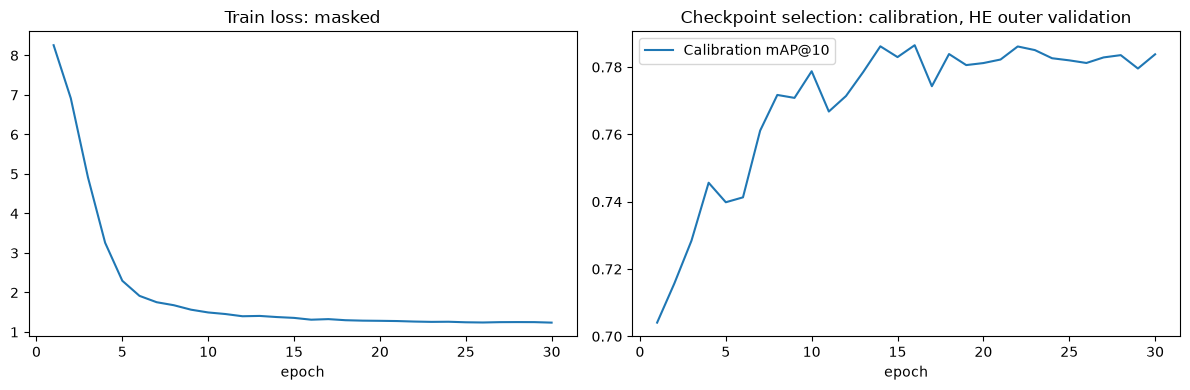

In [8]:
selected_config = config_from_trial(winner, epochs=OUTER_EPOCHS, seed=FINALIST_SEEDS[0])
write_json(RESULTS_DIR / 'selected_config.json', asdict(selected_config))
print(json.dumps(asdict(selected_config), ensure_ascii=False, indent=2))
if RUN_SELECTED_TRAINING:
    selected_result = fit_masked_selected(rows, split, DEVICE, selected_config,
                                         SELECTED_WEIGHTS, SELECTED_RESULTS)
else:
    selected_result = json.loads((SELECTED_RESULTS / 'summary.json').read_text())
print(selected_result)

history = json.loads((SELECTED_RESULTS / 'history.json').read_text())
epochs = [r['epoch'] for r in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [r['train']['loss'] for r in history])
axes[0].set_title('Train loss: masked')
axes[1].plot(epochs, [r['validation']['mAP_at_10'] for r in history], label='Calibration mAP@10')
axes[1].set_title('Checkpoint selection: calibration, НЕ outer validation')
for ax in axes: ax.set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Экспорт и однократная итоговая оценка

Экспорт в новую папку с проверкой PyTorch ↔ ONNX на маскированном кропе. После выбора checkpoint считаются raw и фиксированный streaming reranking (20/3/0.5), пороги отдельно подбираются только на calibration.

**ONNX содержит только OSNet + BNNeck. YOLO и закрашивание выполняются перед ONNX**, их нельзя пропускать при дальнейшем подключении модели. Маски нужно применять и при построении gallery, и к запросам.

MVP не переключается автоматически. Outer validation уже использовалась в прошлых экспериментах проекта, поэтому даже этот итог не является новым независимым тестом.

In [9]:
if RUN_EXPORT:
    report = export_selected(rows, split, SELECTED_WEIGHTS, SELECTED_RESULTS, run_signature)
else:
    report = _load(SELECTED_RESULTS / 'evaluation.json')
print('Checkpoint epoch:', report['checkpoint_epoch'])
for mode in ('raw', 'reranked'):
    print(mode, '| threshold:', report['scores'][mode]['threshold'])
    print(json.dumps(report['scores'][mode]['validation'], ensure_ascii=False, indent=2))
print('Результаты:', SELECTED_RESULTS / 'evaluation.json')
print('MVP остался без изменений.')

/Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/lib/python3.11/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:2855: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  symbolic_helper.check_training_mode(use_input_stats, "instance_norm")


Checkpoint epoch: 16
raw | threshold: 0.5620952844619751
{
  "mAP": 0.7563985972256648,
  "mAP_at_10": 0.7563985972256648,
  "full_mAP": 0.7735698005592485,
  "mINP": 0.7085045289428042,
  "Rank_1": 0.7651821862348178,
  "Rank_5": 0.8987854251012146,
  "candidate_precision": 0.7715736040609137,
  "candidate_recall": 0.6972477064220184,
  "candidate_F1": 0.7325301204819278,
  "TNR": 0.7419354838709677,
  "PR_AUC": 0.904923713036137,
  "candidate_score": 0.7353517294986397,
  "known_queries": 247,
  "unknown_queries": 62,
  "TP": 152,
  "FP": 45,
  "FN": 66,
  "TN": 46,
  "open_set_FP": 16,
  "true_refusals": 46
}
reranked | threshold: 0.5620952844619751
{
  "mAP": 0.7765178437546858,
  "mAP_at_10": 0.7765178437546858,
  "full_mAP": 0.7735698005592485,
  "mINP": 0.7085045289428042,
  "Rank_1": 0.7692307692307693,
  "Rank_5": 0.8461538461538461,
  "candidate_precision": 0.7766497461928934,
  "candidate_recall": 0.6986301369863014,
  "candidate_F1": 0.7355769230769232,
  "TNR": 0.741935483

## 9. Что прислать после завершения

Достаточно написать «обучение завершилось». Для анализа сохраняются:

- results/<RUN_NAME>/study_summary.json;
- results/<RUN_NAME>/stage2_top4_summary.json;
- results/<RUN_NAME>/stage3_top2_seeds_summary.json;
- results/<RUN_NAME>/selected_config.json;
- results/<RUN_NAME>/selected/history.json, summary.json и evaluation.json;
- weights/<RUN_NAME>/selected/best_map.pt и osnet_masked_best_map.onnx.

Подробный протокол — README.md рядом с notebook. Новый запуск не гарантирует улучшения: он проверяет адаптацию OSNet к маскам, в отличие от уже проведённого добавления масок только на инференсе.